# 📊 FinDataMining
Notebook 02: **Transformación de Datos**

---

## Preliminares

In [39]:
import pandas as pd
import numpy as np
from src.config import (
    raw_data_file, clean_data_file, market_index_file
)
%load_ext autoreload
%autoreload 2
from src.clean_transform import corregir_anomalias, imputar_info
from src.extract import obtener_cols_financieras
from src.transform import *

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [40]:
# Abrir archivo raw_data
df = pd.read_parquet(raw_data_file)

# Se asegura el ordenamiento por fecha
df = df.sort_values(by='Date').reset_index(drop=True)

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 37498 entries, 0 to 37497
Data columns (total 31 columns):
 #   Column                           Non-Null Count  Dtype         
---  ------                           --------------  -----         
 0   Ticker                           37498 non-null  object        
 1   Date                             37498 non-null  datetime64[ns]
 2   Close                            37498 non-null  float64       
 3   Open                             37498 non-null  float64       
 4   Volume                           37498 non-null  float64       
 5   CashAndCashEquivalents           37417 non-null  float64       
 6   CurrentAssets                    35569 non-null  float64       
 7   CurrentDebt                      29559 non-null  float64       
 8   CurrentLiabilities               35574 non-null  float64       
 9   FinancialsSource                 37498 non-null  object        
 10  LongTermDebt                     35339 non-null  float64  

## Limpieza de Datos

Limpiar cadenas en Industry y Sector: 
* sin espacios iniciales ni finales.
* primer letra en mayúscula.
* se reemplaza el símbolo '&' por 'And'.

Además se convierten a variables de tipo "Category"

In [41]:
df_clean = limpiar_industry_y_sector(df)

# Ver cambios
df_clean[['Industry', 'Sector']].head()

,Industry,Sector
0,Personal Services,Consumer Cyclical
1,Grocery Stores,Consumer Defensive
2,Restaurants,Consumer Cyclical
3,Entertainment,Communication Services
4,Industrial Distribution,Industrials


In [42]:
# Valores únicos en Sector
df_clean['Sector'].value_counts()

Sector
Industrials               7609
Consumer Cyclical         7597
Technology                5972
Healthcare                3633
Financial Services        3010
Consumer Defensive        2628
Energy                    2178
Basic Materials           1983
Communication Services    1521
Real Estate                753
Utilities                  614
Name: count, dtype: int64

In [43]:
# Valores únicos en Industry
df_clean['Industry'].value_counts()

Industry
Specialty Industrial Machinery           1235
Software Application                      912
Semiconductors                            897
Engineering And Construction              887
Restaurants                               827
                                         ... 
Marine Shipping                            68
Utilities Diversified                      68
Reit Hotel And Motel                       68
Utilities Independent Power Producers      68
Coking Coal                                64
Name: count, Length: 117, dtype: int64

* Para mejorar la visualización de los datos, se expresan las columnas financieras y volumen en millones:

In [44]:
df_clean = columnas_en_millones(df_clean)

### Corrección de anomalías

#### Error de importes en Balance General
Se analiza el siguiente registro, el cual muestra valores extremadamente elevados en el Balance:

In [45]:
# Caso 1: Error de importes en el Galance General
condicion_1 = df_clean[(df_clean['Ticker'] == 'IIIN') & (df_clean['Date'] == '2021-12-01')]

# Mostrar el registro
print(condicion_1.T)

                                                7455
Ticker                                          IIIN
Date                             2021-12-01 00:00:00
Close                                      31.841917
Open                                       32.969701
Volume                                        2.4059
CashAndCashEquivalents                       89884.0
CurrentAssets                               246906.0
CurrentDebt                                      NaN
CurrentLiabilities                           88672.0
FinancialsSource                              simFin
LongTermDebt                                     NaN
StockholdersEquity                          302038.0
TotalAssets                                 390710.0
TotalDebt                                        NaN
TotalLiabilities                             88672.0
TotalNoncurrentLiabilities                    19.306
TotalRevenue_TTM                             590.601
GrossProfit_TTM                              1

* Se observa una desconexión en los valores del Balance General, están multiplicados por 1.000.
* El caso se detecto ya que arrojaba valores extremos en las métricas.

Se corrigirá dividiendo las columnas afectadas por 1.000.

#### Anomalías de signo: 

Las siguientes variables no pueden ser negativas:
* `TotalRevenue`
* `CurrentDebt`
* `LongTermDebt`
* `DepreciationAndAmortization`

In [46]:
# Caso 2:  TotalRevenue negativo
condicion_2 = df_clean['TotalRevenue_TTM'] < 0

# Mostrar los registros
cols_a_visualizar_2 = ['Ticker', 'Date', 'TotalRevenue_TTM', 'OperatingIncome_TTM']
anomalias = df_clean.loc[condicion_2, cols_a_visualizar_2]
print(anomalias)
print("Cantidad de casos:", len(anomalias))

     Ticker       Date  TotalRevenue_TTM  OperatingIncome_TTM
2435    ALB 2021-03-01      -2086.891840            59.346314
2697    EXE 2021-04-01      -5544.000000           218.000000
2800    ALB 2021-04-01      -2086.891840            59.346314
3154    ALB 2021-05-01      -2086.891840            59.346314
3374    EXE 2021-05-01      -5544.000000           218.000000
4047    ALB 2021-06-01       -285.539893           247.382876
4086    EXE 2021-06-01      -2522.666667           525.333333
4410    ALB 2021-07-01       -285.539893           247.382876
4660    EXE 2021-07-01      -2522.666667           525.333333
4782    ALB 2021-08-01       -285.539893           247.382876
4835    EXE 2021-08-01      -2522.666667           525.333333
5775    EXE 2021-09-01      -1199.000000           187.000000
5849    EXE 2021-10-01      -1199.000000           187.000000
6897    EXE 2021-11-01      -1199.000000           187.000000
6937    EXE 2021-12-01      -1268.000000           -55.000000
7815    

* No se puede concluir que se traten de alteraciones de signo en el parseo de datos de simFin. Se observan casos en los que el valor absoluto de `TotalRevenue` es mayor que `OperatingIncome`, es imposible que los resultados sean mayores que las ventas.

Se opta por asignar todos estos valores anómalos a NaN.

In [47]:
# Caso 3:  Deuda negativa
condicion_3 = (df_clean['CurrentDebt'] < 0) | (df_clean['LongTermDebt'] < 0)

# Ver registros
cols_a_visualizar_3 = ['Ticker', 'Date', 'TotalDebt', 'CurrentDebt', 'LongTermDebt']
anomalias = df_clean.loc[condicion_3, cols_a_visualizar_3]
print(anomalias)
print("Cantidad de casos:", len(anomalias))

      Ticker       Date  TotalDebt  CurrentDebt  LongTermDebt
11923    IEP 2022-09-01        NaN     -746.000      7134.000
12388    IEP 2022-10-01        NaN     -746.000      7134.000
13000    IEP 2022-11-01        NaN     -746.000      7134.000
13561    IEP 2022-12-01        NaN     -745.000      7127.000
14245    IEP 2023-01-01        NaN     -745.000      7127.000
14943    IEP 2023-02-01        NaN     -745.000      7127.000
15486    IEP 2023-03-01        NaN     -745.000      7981.000
15769    IEP 2023-04-01        NaN     -745.000      7981.000
16263    IEP 2023-05-01        NaN     -745.000      7981.000
16826    IEP 2023-06-01        NaN     -745.000      7755.000
21727   STLD 2024-03-01        NaN      459.987     -3286.537
22371   STLD 2024-04-01        NaN      459.987     -3286.537
23209   STLD 2024-05-01        NaN      459.987     -3286.537
23530   STLD 2024-06-01        NaN      425.696     -3570.028
24062   STLD 2024-07-01        NaN      425.696     -3570.028
24893   

* Se observan en las filas que TotalDebt es NaN, se infiere que la API intenta sumar y al encontrar signo negativo arruina la ecuación, devolviendo nulos.
* Al faltar TotalDebt, no se puede confirmar que se traten de errores de signo.

Se asignan dichos valores a NaN.

#### Negativos en `DepreciationAndAmortization`: 

Se analizan los casos separando los registros según provengan de `yfinance` o de `simFin`:

In [48]:
# Caso 4:  Depreciación y Amortización negativa de yfinance
condicion_4 = (df_clean['DepreciationAndAmortization_TTM'] < 0) & (df_clean['FinancialsSource']=='yfinance')

# Ver registros
cols_a_visualizar_4 = ['Ticker', 'Date', 'DepreciationAndAmortization_TTM', 'EBITDA_TTM', 'OperatingIncome_TTM', 'FinancialsSource', 'Sector']
anomalias = df_clean.loc[condicion_4, cols_a_visualizar_4]
print(anomalias)
print("Cantidad de casos:", len(anomalias))

      Ticker       Date  DepreciationAndAmortization_TTM  EBITDA_TTM  \
30907   CAKE 2025-08-01                       -50.956000     367.848   
30911    DAR 2025-08-01                      -254.484000     765.060   
30912    GPI 2025-08-01                       -61.600000    1126.800   
30913     IP 2025-08-01                      -520.000000    2956.000   
30915    LVS 2025-08-01                      -643.000000    4776.000   
...      ...        ...                              ...         ...   
37279    AAL 2026-07-01                     -1872.000000    2046.000   
37308    RNR 2026-07-01                       -42.217000         NaN   
37410    IMO 2026-07-01                     -1478.259468    6404.000   
37436   SKYW 2026-07-01                      -357.784000     654.435   
37471   LBRT 2026-07-01                      -510.968000     724.280   

       OperatingIncome_TTM FinancialsSource              Sector  
30907              220.684         yfinance   Consumer Cyclical  
309

* Ya que son unos pocos valores recientes y la D&A no es un gasto volátil (es la es la distribución contable de un costo de capital a lo largo de los años), se decide asignarlos a NaN para luego ser imputados por medias móviles.

In [49]:
# # Caso 5: Depreciación y Amortización negativa de simFin
condicion_5 = (df_clean['DepreciationAndAmortization_TTM'] < 0) & (df_clean['FinancialsSource']=='simFin')

# Ver registros
anomalias = df_clean.loc[condicion_5, cols_a_visualizar_4] # mismas columnas que el caso anterior
print(anomalias)
print("Cantidad de casos:", len(anomalias))

      Ticker       Date  DepreciationAndAmortization_TTM  EBITDA_TTM  \
12      BURL 2020-09-01                         -217.616         NaN   
15        DY 2020-09-01                         -176.516         NaN   
18       TGT 2020-09-01                        -2168.000         NaN   
19       LOW 2020-09-01                        -1308.000         NaN   
23       ADI 2020-09-01                         -428.308         NaN   
...      ...        ...                              ...         ...   
31950    JBL 2025-09-01                          -58.000         NaN   
31977    CCL 2025-09-01                        -2656.000         NaN   
31992   LULU 2025-09-01                           -4.365         NaN   
31995   CASY 2025-09-01                         -403.647         NaN   
32390    WGO 2025-10-01                          -22.800         NaN   

       OperatingIncome_TTM FinancialsSource              Sector  
12                -324.896           simFin   Consumer Cyclical  
15 

* `simFin` utiliza signo negativo para esta columna, lo cual es incorrecto. 

Dichos valores serán convertidos a positivos.

In [50]:
# Se aplican los cambios mencionados
df_clean = corregir_anomalias(df_clean)

## Tratamiento Inicial de Missings

Se realiza la imputación sobre las variables originales de los Estados Financieros.

In [51]:
# Ver incidencia de missings
mostrar_missings(df_clean)

EBITDA_TTM                         0.840952
TotalDebt                          0.833458
FreeCashFlow_TTM                   0.831778
DepreciationAndAmortization_TTM    0.467892
DateAdded                          0.439597
CurrentDebt                        0.211985
GrossProfit_TTM                    0.067097
LongTermDebt                       0.057870
TotalNoncurrentLiabilities         0.052723
CurrentAssets                      0.051443
CurrentLiabilities                 0.051309
CapitalExpenditure_TTM             0.018588
CashAndCashEquivalents             0.002160
TotalRevenue_TTM                   0.001333
BasicAverageShares_TTM             0.001173
OperatingIncome_TTM                0.000880
NetIncome_TTM                      0.000880
OperatingCashFlow_TTM              0.000613
FinancingCashFlow_TTM              0.000613
InvestingCashFlow_TTM              0.000613
StockholdersEquity                 0.000480
TotalAssets                        0.000347
TotalLiabilities                

Si llegasen a quedar datos de Sector e Industry perdidos (a veces falla la descarga), se pueden volver a asignar desde aquí para no repetir todo el flujo de extracción:

In [52]:
#df_clean = recuperar_info(df_clean)

Se pueden imputar manualmente casos persistentes completando los datos dentro de la función imputar_info del módulo `clean_transform`:

In [53]:
# df_clean = imputar_info(df_clean)

* Se imputan parte de los NaNs en Variables Financieras antes de calcular métricas, 
mediante las relaciones contables entre ellas:

In [54]:
df_financials_imputed = imputar_equivalencias_financieras(df_clean)
mostrar_missings(df_financials_imputed)

DateAdded                     0.439597
GrossProfit_TTM               0.067097
LongTermDebt                  0.038935
TotalDebt                     0.038935
CurrentDebt                   0.038935
CapitalExpenditure_TTM        0.018588
FreeCashFlow_TTM              0.015734
CashAndCashEquivalents        0.002160
TotalRevenue_TTM              0.001333
BasicAverageShares_TTM        0.001173
EBITDA_TTM                    0.000880
NetIncome_TTM                 0.000880
OperatingIncome_TTM           0.000880
InvestingCashFlow_TTM         0.000613
FinancingCashFlow_TTM         0.000613
OperatingCashFlow_TTM         0.000613
StockholdersEquity            0.000480
CurrentAssets                 0.000347
CurrentLiabilities            0.000347
TotalLiabilities              0.000347
TotalNoncurrentLiabilities    0.000347
TotalAssets                   0.000347
dtype: float64

In [55]:
# Se imputan las columnas financieras, por su media o mediana móvil según sus asimetrías
df_financials_imputed = imputar_numericas(df_financials_imputed)
mostrar_missings(df_financials_imputed)

DateAdded                     0.439597
GrossProfit_TTM               0.066324
LongTermDebt                  0.037282
TotalDebt                     0.037282
CurrentDebt                   0.037282
CapitalExpenditure_TTM        0.018268
FreeCashFlow_TTM              0.015414
CashAndCashEquivalents        0.001893
TotalRevenue_TTM              0.001253
BasicAverageShares_TTM        0.001173
EBITDA_TTM                    0.000880
NetIncome_TTM                 0.000880
OperatingIncome_TTM           0.000880
InvestingCashFlow_TTM         0.000613
FinancingCashFlow_TTM         0.000613
OperatingCashFlow_TTM         0.000613
StockholdersEquity            0.000267
CurrentAssets                 0.000213
CurrentLiabilities            0.000213
TotalLiabilities              0.000213
TotalNoncurrentLiabilities    0.000213
TotalAssets                   0.000213
dtype: float64

Se remueven los Missings remanentes en columnas numéricas relevantes, es decir excluyendo las siguientes columnas que no se utilizan en el pipeline actual:
- `GrossProfit`
- `FinancingCashFlow`
- `InvestingCashFlow`

In [56]:
cols_no_relevantes = ['GrossProfit_TTM', 'FinancingCashFlow_TTM', 'InvestingCashFlow_TTM']
df_financials_imputed = quitar_nulos_relevantes(df_financials_imputed, cols_no_relevantes)
mostrar_missings(df_financials_imputed)

DateAdded          0.439847
GrossProfit_TTM    0.052761
dtype: float64

In [57]:
df_financials_imputed.info()

<class 'pandas.core.frame.DataFrame'>
Index: 35310 entries, 8 to 37497
Data columns (total 31 columns):
 #   Column                           Non-Null Count  Dtype         
---  ------                           --------------  -----         
 0   Ticker                           35310 non-null  object        
 1   Date                             35310 non-null  datetime64[ns]
 2   Close                            35310 non-null  float64       
 3   Open                             35310 non-null  float64       
 4   Volume                           35310 non-null  float64       
 5   CashAndCashEquivalents           35310 non-null  float64       
 6   CurrentAssets                    35310 non-null  float64       
 7   CurrentDebt                      35310 non-null  float64       
 8   CurrentLiabilities               35310 non-null  float64       
 9   FinancialsSource                 35310 non-null  object        
 10  LongTermDebt                     35310 non-null  float64       

## Feature Engineering

* Se reemplaza `DateAdded` por nueva feature `YearsSinceAdded`, donde los valores missing corresponden a cero años (no pertenecen al índice S&P 500):

In [58]:
df_with_features = crear_years_since_added(df_financials_imputed)

* Calcular métricas financieras y ratios de valuación:

In [59]:
df_with_features = calcular_metricas(df_with_features)
mostrar_missings(df_with_features)

DebtToEquity       0.069159
GrossProfit_TTM    0.052761
ReturnOnEquity     0.003483
dtype: float64

Convertir `volume`:
* Se reemplaza el volumen total trimestral por su promedio diario (AverageDailyVolume), ya que es el valor estándar utilizado en finanzas. El cálculo es aproximado, dividiendo los valores de `Volume` entre 21 (252 días hábiles entre 12).
* Se aplica lag de 1 período a AverageDailyVolume para evitar Data Leakage.

In [60]:
df_with_features = convertir_volumen_a_adv(df_with_features)
columnas_lag1 = ['AverageDailyVolume']
df_with_features = calcular_lag(df_with_features, columnas_lag1, months=1)

Cálculo de los crecimientos y las aceleraciones:
* Primero se calculan las tasas de crecimiento para las variables indicadas en "crecimiento_cols", incluyendo las variaciones anuales (YoY) y trimestrales (QoQ) .
* Luego se calculan las aceleraciones (Momento - Tendencia), definidas como la diferencia entre la tasa de cambio de corto plazo (QoQ) y la de largo plazo (YoY). 

In [61]:
# Calcular crecimientos
crecimiento_cols = [
    'TotalRevenue_TTM',
    'EBITDA_TTM',
    'FreeCashFlow_TTM',
    'CapitalExpenditure_TTM',
    'AverageDailyVolume_Lag1'
]
df_with_features = calcular_crecimientos(df_with_features, crecimiento_cols)
mostrar_missings(df_with_features)

CapitalExpenditure_TTM_YoY     0.183716
AverageDailyVolume_Lag1_YoY    0.183517
FreeCashFlow_TTM_YoY           0.183489
EBITDA_TTM_YoY                 0.183489
TotalRevenue_TTM_YoY           0.183489
DebtToEquity                   0.069159
GrossProfit_TTM                0.052761
CapitalExpenditure_TTM_QoQ     0.046049
AverageDailyVolume_Lag1_QoQ    0.045993
FreeCashFlow_TTM_QoQ           0.045993
TotalRevenue_TTM_QoQ           0.045964
EBITDA_TTM_QoQ                 0.045964
ReturnOnEquity                 0.003483
AverageDailyVolume_Lag1        0.000028
dtype: float64

Antes de calcular las aceleraciones, se tratan los valores nulos en los valores iniciales de las columnas de crecimiento. Se imputan con las tasas de inflación promedio históricas de EE.UU. (asumiendo crecimiento neutral) y se crean variables flag `IsMissing`: 

In [62]:
df_with_features = imputar_crecimientos(df_with_features, crecimiento_cols)
mostrar_missings(df_with_features)

DebtToEquity               0.069159
GrossProfit_TTM            0.052761
ReturnOnEquity             0.003483
AverageDailyVolume_Lag1    0.000028
dtype: float64

* Se calculan las aceleraciones, definidas como la tasa de crecimiento de corto plazo (QoQ) menos la de largo (YoY):

In [63]:
df_with_features = calcular_aceleraciones(df_with_features, crecimiento_cols)

* Se calculan los retornos mensuales, completando missings con cero (valor neutral). Luego se calculan la varianza del activo y la covarianza con el mercado para obtener el coeficiente Beta de corto plazo (ShortTermBeta sobre una ventana de 12 meses):

In [64]:
# Se abre el fichero de precios del Índice del Mercado para calcular las covarianzas
df_index = pd.read_parquet(market_index_file)

df_with_features = calcular_retornos_y_betas(df_with_features, df_index)
mostrar_missings(df_with_features)

DebtToEquity               0.069159
GrossProfit_TTM            0.052761
Variance                   0.023393
ShortTermBeta              0.023393
ReturnOnEquity             0.003483
AverageDailyVolume_Lag1    0.000028
dtype: float64

## Tratamiento Final de Missings

Se gestionan los valores perdidos remanentes en las variables nuevas.

In [65]:
# Se aplica la imputación de medias móviles sobre las nuevas variables
df_imputed = imputar_numericas(df_with_features)
mostrar_missings(df_imputed)

DebtToEquity               0.064826
GrossProfit_TTM            0.052053
Variance                   0.023393
ShortTermBeta              0.023393
ReturnOnEquity             0.002549
AverageDailyVolume_Lag1    0.000028
dtype: float64

* Se eliminan missings remanentes:

In [66]:
cols_no_relevantes = [
    'GrossProfit_TTM',
    ]
df_imputed = quitar_nulos_relevantes(df_imputed, cols_no_relevantes)
mostrar_missings(df_imputed)

GrossProfit_TTM    0.054742
dtype: float64

## Análisis Exploratorio de Datos

In [67]:
df_imputed.info()

<class 'pandas.core.frame.DataFrame'>
Index: 32242 entries, 3 to 35309
Data columns (total 77 columns):
 #   Column                                 Non-Null Count  Dtype         
---  ------                                 --------------  -----         
 0   Ticker                                 32242 non-null  object        
 1   Date                                   32242 non-null  datetime64[ns]
 2   Close                                  32242 non-null  float64       
 3   Open                                   32242 non-null  float64       
 4   CashAndCashEquivalents                 32242 non-null  float64       
 5   CurrentAssets                          32242 non-null  float64       
 6   CurrentDebt                            32242 non-null  float64       
 7   CurrentLiabilities                     32242 non-null  float64       
 8   FinancialsSource                       32242 non-null  object        
 9   LongTermDebt                           32242 non-null  float64    

In [68]:
# Coeficientes de asimetría
mostrar_asimetrias(df_imputed)

AssetToMarket                            113.276516
BookToMarket                             100.549384
MonthlyExcessReturn                       56.781712
Variance                                  54.990941
MonthlyReturn                             45.721638
CapExToRevenue                            43.658961
RevenueYield                              37.048764
TotalRevenue_TTM_QoQ                      35.777899
DebtToEquity                              34.503431
FcfToEbitda                               29.447627
NetDebtToEbitda                           25.137561
CurrentDebt                               24.650032
Open                                      23.590246
Close                                     23.569768
Return_IsMissing                          21.706981
AverageDailyVolume_Lag1                   17.815552
TotalRevenue_TTM_YoY                      16.315125
TotalDebt                                 15.513568
DepreciationAndAmortization_TTM           13.461519
CashAndCashE

In [69]:
# Analizar la distribución de una columna específica
df_imputed['Variance'].describe().round(4).T

count    32242.0000
mean         0.0191
std          0.4614
min          0.0000
25%          0.0040
50%          0.0068
75%          0.0118
max         34.5138
Name: Variance, dtype: float64

In [70]:
# Analizar extremos
df_max = df_imputed.loc[df_imputed['MonthlyReturn'].idxmax()]
df_max

Ticker                                    GME
Date                      2021-02-01 00:00:00
Close                               25.434999
Open                                79.139999
CashAndCashEquivalents                  445.9
                                 ...         
MonthlyReturn                       15.661053
ShortTermBeta                      -20.396882
Variance                            34.513825
Return_IsMissing                            0
MonthlyExcessReturn                 -0.696375
Name: 13806, Length: 77, dtype: object

* **Short squeeze** de GameStop, se trata de un outlier real del mercado.

In [71]:
# Mínimo
df_min = df_imputed.loc[df_imputed['EbitdaYield'].idxmin()]
df_min

Ticker                                   CPHI
Date                      2021-06-01 00:00:00
Close                                   360.0
Open                                    290.0
CashAndCashEquivalents                0.53453
                                 ...         
MonthlyReturn                       -0.246753
ShortTermBeta                       -0.729718
Variance                             0.048553
Return_IsMissing                            0
MonthlyExcessReturn                  0.228387
Name: 7513, Length: 77, dtype: object

Cont


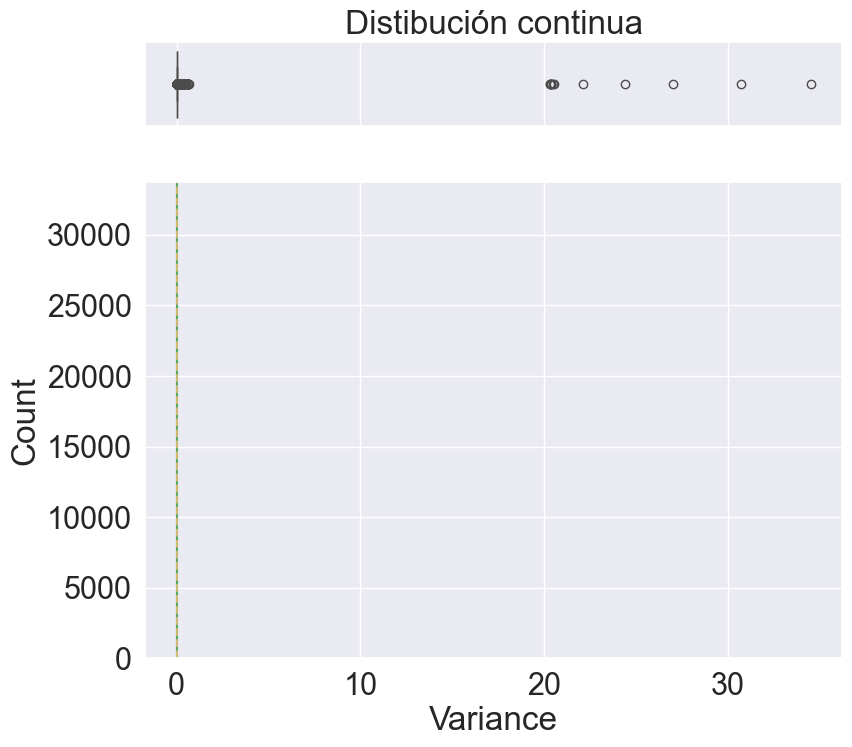

In [72]:
# Graficar
columna_a_graficar = 'Variance' # indicar columna para el gráfico
graficar(df_imputed[columna_a_graficar])

## Transformaciones Iniciales

* Transformaciones logarítmicas:

In [73]:
columnas_log = [ 
    'DebtToEquity',
    'CurrentRatio',
    'MarketCap' 
    ]

df_transformed = transformar_log(
    df_imputed, 
    columnas_log, 
    calculo_1p=True
    )

print("### Coeficientes de asimetría antes y después de transformar: ###")
for col in columnas_log:
    print(f'  - {col}:', df_imputed[col].skew(), '->', df_transformed[f'{col}_Log1p'].skew())

### Coeficientes de asimetría antes y después de transformar: ###
  - DebtToEquity: 34.50343108029007 -> 2.659815830356849
  - CurrentRatio: 5.6822908968049015 -> 0.9997722620883457
  - MarketCap: 9.467975442633282 -> -0.05496249318016579


* Transformaciones Yeo-Johnson (trata columnas que puedan tener valores negativos):

In [74]:
columnas_yeo = [ 
    'MonthlyReturn',
    'TotalRevenue_TTM_QoQ',
    'FcfToEbitda',
    'TotalRevenue_TTM_YoY',
    'AverageDailyVolume_Lag1_QoQ',
    'AverageDailyVolume_Lag1_YoY',
    'EBITDA_TTM_QoQ',
    'EBITDA_TTM_YoY',
    'OperatingMargins', 
    'ProfitMargins', 
    'ReturnOnAssets', 
    'ReturnOnEquity',
    'EnterpriseValue',
    'Variance'    
    ]

df_transformed = transformar_yeo_johnson(
    df_transformed, 
    columnas_yeo
    )

print("### Coeficientes de asimetría antes y después de transformar: ###")
for col in columnas_yeo:
    print(f'  - {col}:', df_imputed[col].skew(), '->', df_transformed[f'{col}_Yeo'].skew())

### Coeficientes de asimetría antes y después de transformar: ###
  - MonthlyReturn: 45.72163767738168 -> -0.19907290796753216
  - TotalRevenue_TTM_QoQ: 35.77789933921784 -> -3.5871939865886846
  - FcfToEbitda: 29.44762673682988 -> 1.3743946472796904
  - TotalRevenue_TTM_YoY: 16.315124715975713 -> -1.266959433063771
  - AverageDailyVolume_Lag1_QoQ: 8.207924474017322 -> -0.3018376033710524
  - AverageDailyVolume_Lag1_YoY: 7.039275922076571 -> -0.29110737654005836
  - EBITDA_TTM_QoQ: 4.337891189561283 -> -1.79323884405274
  - EBITDA_TTM_YoY: 3.2993023547927645 -> -1.4881963530188842
  - OperatingMargins: -43.70382657896556 -> 1.0308074526689504
  - ProfitMargins: -44.519117115090815 -> 2.084413280550082
  - ReturnOnAssets: -41.13512772714934 -> 1.5496309786632552
  - ReturnOnEquity: -47.254662954843425 -> 8.048006649117779
  - EnterpriseValue: 9.235157722974797 -> 2.083759483666346
  - Variance: 54.99094057280005 -> 0.9203992811383362


Cont


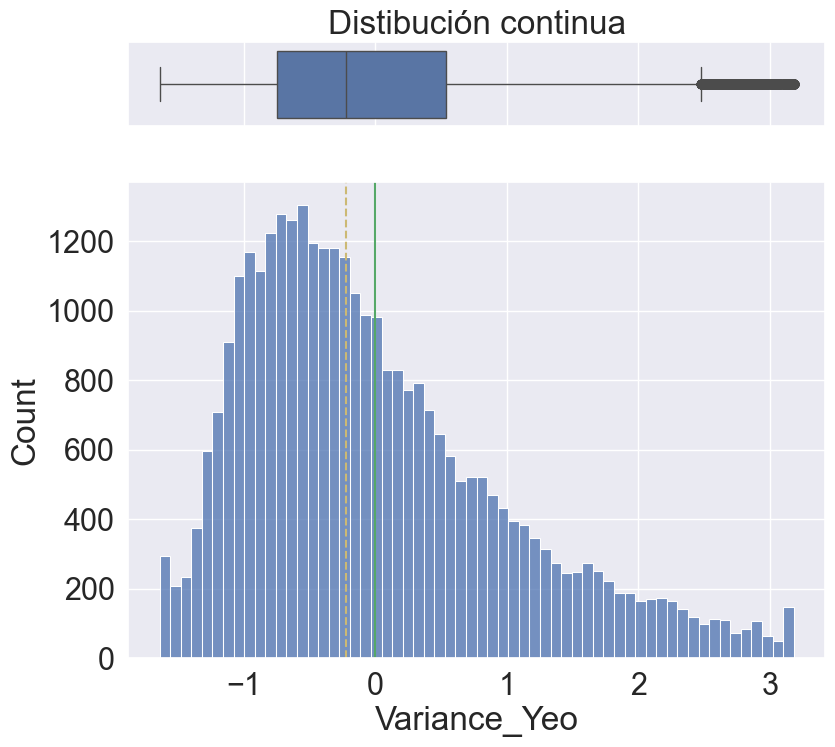

In [75]:
# Visualizar cambios
columna_a_graficar = 'Variance_Yeo' # indicar columna a graficar
graficar(df_transformed[columna_a_graficar])

Se convierten variables contínuas a categóricas agrupando por cuantiles:
* *Variable objetivo*:  `MonthlyExcessReturn`

In [ ]:
cols_a_agrupar = [
    'MonthlyExcessReturn'
]

# Aplicar la categorización
for col in cols_a_agrupar:
    df_transformed = categorizar_en_cuantiles(df_transformed, columna=col, num_cuantiles=5)

MonthlyExcessReturn_Quantile
4    106
3    105
1    103
2    103
5    103
Name: count, dtype: int64

In [ ]:
# Crear label binaria: para simplificar la clasificación, 1 si es el Quintil 5
df_transformed['Target_Top_Quintile'] = np.where(df_transformed['MonthlyExcessReturn_Quantile'] == 5, 1, 0)

# Verificar tickers únicos por clase en la última fecha
(df_transformed.sort_values(by='Date')
               .drop_duplicates(subset=['Ticker'], keep='last')
               ['Target_Top_Quintile']
               .value_counts())

Target_Top_Quintile
0    417
1    103
Name: count, dtype: int64

## Tratamiento Inicial de Outliers

Se recortan variables de rendimiento con valores extremos, aplicando limites lógicos.

In [79]:
# Columnas a recortar:
tuplas_clipping = [
    ('EbitdaYield', -2.0),
    ('EbitdaYield', 2.0),
    ('EarningsYield', -2.0),
    ('EarningsYield', 2.0),
    ('RevenueYield', -2.0),         
    ('TotalRevenue_TTM_Acceleration', -2.0),
    ('TotalRevenue_TTM_Acceleration', 2.0),
    ('CapExToRevenue', 1.0)
    ] 
for col, limit in tuplas_clipping:
    df_transformed = aplicar_clipping(df_transformed, columna=col, limite = limit)

Cont


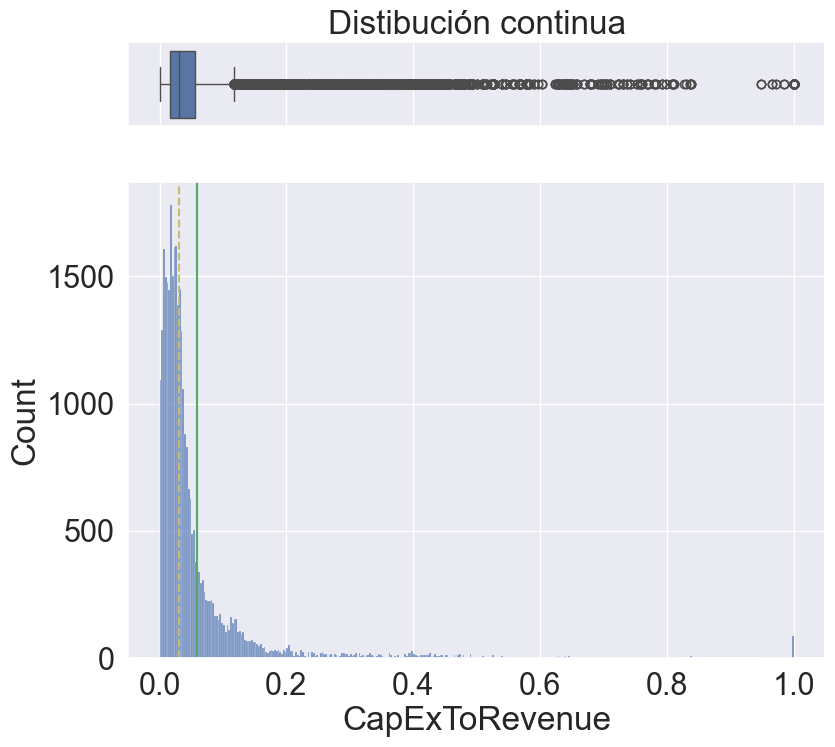

In [80]:
# Graficar
graficar(df_transformed['CapExToRevenue'])

Se winsorizan los valores atipicos en las variables continuas que cumplan los siguientes criterios:

Para variables simetricas:
* A mas de 3 desviaciones tipicas de la media.
* Mas de 3 rangos intercuartilicos.

Para variables asimetricas (modulo del coeficiente de asimetrica mayor a 1):
* A mas de 3 MADs de la mediana.
* Mas de 3 rangos intercuartilicos.

In [81]:
# Definir columnas que saltean la "winsorización"
# Columnas de los Estados Financieros
cols_fin_clean = obtener_cols_financieras(incluirTTM=True)

# Columnas flag
cols_flag = obtener_cols_flag(df_transformed)

columnas_intactas = cols_fin_clean + cols_flag + [
    'Date', 
    'Ticker',
    'Close',
    'Open',
    'AverageDailyVolume_Lag1'
    ]

# Separar el dataset
df_passthrough = df_transformed[columnas_intactas].copy()
df_transformed_features = df_transformed.drop(columns=columnas_intactas)

# Winsorizar
df_cont_transformed = df_transformed_features.select_dtypes(include="number")
df_winsor = df_cont_transformed.apply(lambda x: gestiona_outliers(x, clas='winsor'))

# Coeficientes de asimetría luego de winsorizar
mostrar_asimetrias(df_winsor)

CapExToRevenue                          4.224182
BookToMarket                            3.954259
RevenueYield                            2.958846
ReturnOnEquity_Yeo                      2.955920
EnterpriseValue_Yeo                     2.863893
AssetToMarket                           2.397628
DebtToEquity_Log1p                      2.068250
Target_Top_Quintile                     1.497020
YearsSinceAdded                         1.492736
FcfToEbitda_Yeo                         1.249523
OperatingMargins_Yeo                    1.078675
FreeCashFlow_TTM_YoY                    1.013401
EBITDA_TTM_YoY_Yeo                      0.997428
CurrentRatio_Log1p                      0.955423
Variance_Yeo                            0.920399
EBITDA_TTM_QoQ_Yeo                      0.907090
ReturnOnAssets_Yeo                      0.899307
CapitalExpenditure_TTM_Acceleration     0.831744
FreeCashFlow_TTM_QoQ                    0.813441
ProfitMargins_Yeo                       0.669822
EbitdaYield         

Cont


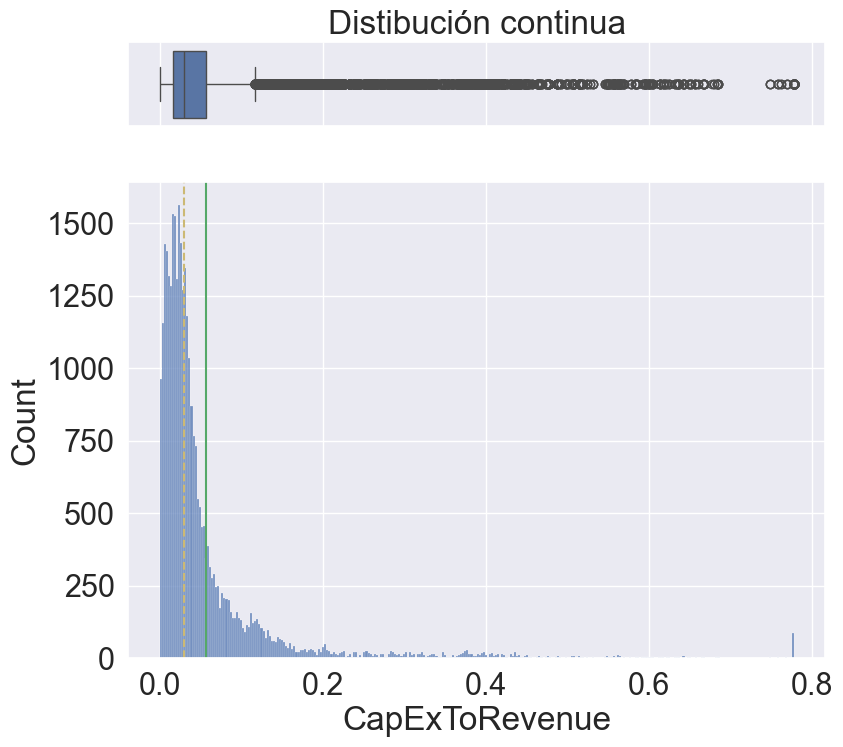

In [82]:
# Visualizar cambios
columna_a_graficar = 'CapExToRevenue' # indicar columna a graficar
graficar(df_winsor[columna_a_graficar])

In [83]:
df_winsor['CapExToRevenue'].describe().T

count    32242.000000
mean         0.057106
std          0.090278
min          0.000000
25%          0.016126
50%          0.030182
75%          0.056369
max          0.777632
Name: CapExToRevenue, dtype: float64

## Transformaciones Finales

Transformaciones post-winsorización

In [84]:
# Logarítmicas
columnas_log = [ 
    'CapExToRevenue'    
    ]

df_transformed_final = transformar_log(
    df_winsor, 
    columnas_log, 
    calculo_1p=True
    )

print("### Coeficientes de asimetría antes y después de transformar: ###")
for col in columnas_log:
    print(f'  - {col}:', df_winsor[col].skew(), '->', df_transformed_final[f'{col}_Log1p'].skew())

### Coeficientes de asimetría antes y después de transformar: ###
  - CapExToRevenue: 4.224181779248621 -> 3.6217780516611193


In [85]:
# Transformaciones Yeo-Johnson
columnas_yeo = [ 
    'BookToMarket',
    'EarningsYield'  
    ]

df_transformed_final = transformar_yeo_johnson(
    df_transformed_final, 
    columnas_yeo
    )

print("### Coeficientes de asimetría antes y después de transformar: ###")
for col in columnas_yeo:
    print(f'  - {col}:', df_winsor[col].skew(), '->', df_transformed_final[f'{col}_Yeo'].skew())

### Coeficientes de asimetría antes y después de transformar: ###
  - BookToMarket: 3.9542586065429988 -> -1.1395481232953375
  - EarningsYield: -3.4246831968603915 -> 1.4364318314793716


Cont


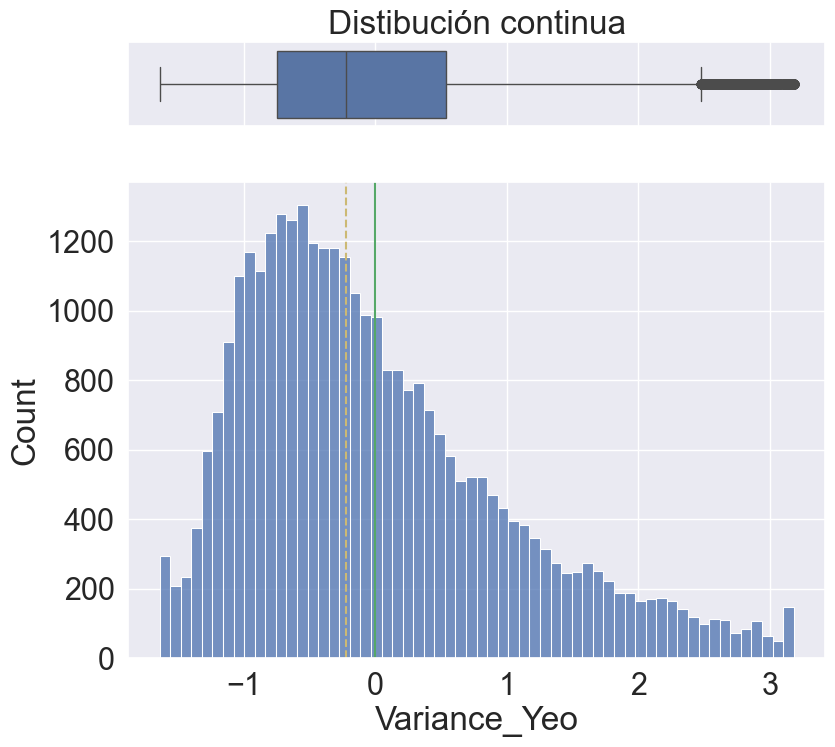

In [86]:
# Visualizar cambios
columna_a_graficar = 'Variance_Yeo' # indicar columna a graficar
graficar(df_transformed_final[columna_a_graficar])

## Tratamiento Final de Outliers

In [87]:
# Columnas a recortar:
tuplas_clipping = [
    ('BookToMarket_Yeo', -3.5),
    ('CapExToRevenue_Log1p', 0.45),
    ('FreeCashFlow_TTM_Acceleration', -10.0),
    ('FreeCashFlow_TTM_Acceleration', 10.0),
    ('ShortTermBeta', -2.5),
    ('ShortTermBeta', 5.0),
    ('RevenueYield', -2.5),
    ('RevenueYield', 7.5),
    ('EarningsYield_Yeo', -5.0),
    ('EarningsYield_Yeo', 5.0)
    ] 
for col, limit in tuplas_clipping:
    df_transformed_final = aplicar_clipping(df_transformed_final, columna=col, limite = limit)

Cont


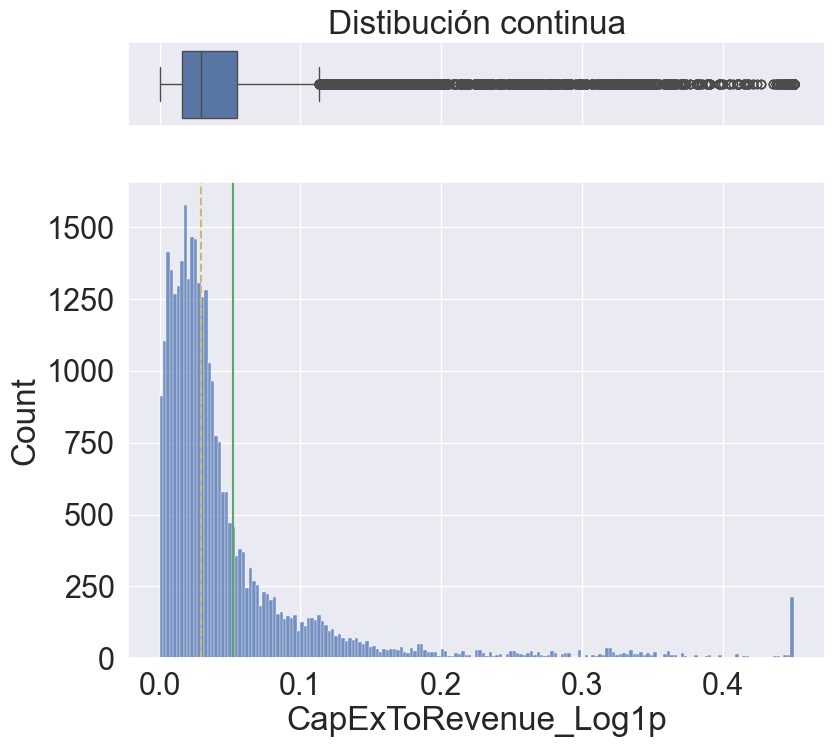

In [88]:
# Graficar
graficar(df_transformed_final['CapExToRevenue_Log1p'])

In [89]:
mostrar_asimetrias(df_transformed_final)

CapExToRevenue_Log1p                    3.281547
ReturnOnEquity_Yeo                      2.955920
EnterpriseValue_Yeo                     2.863893
RevenueYield                            2.585018
AssetToMarket                           2.397628
DebtToEquity_Log1p                      2.068250
Target_Top_Quintile                     1.497020
YearsSinceAdded                         1.492736
FcfToEbitda_Yeo                         1.249523
OperatingMargins_Yeo                    1.078675
FreeCashFlow_TTM_YoY                    1.013401
EBITDA_TTM_YoY_Yeo                      0.997428
CurrentRatio_Log1p                      0.955423
Variance_Yeo                            0.920399
EBITDA_TTM_QoQ_Yeo                      0.907090
ReturnOnAssets_Yeo                      0.899307
CapitalExpenditure_TTM_Acceleration     0.831744
FreeCashFlow_TTM_QoQ                    0.813441
ProfitMargins_Yeo                       0.669822
EbitdaYield                             0.666964
NetDebtToEbitda     

## Concatenación Final y Almacenamiento

In [90]:
df_non_numeric = df_transformed_features.select_dtypes(exclude='number')
# Se unen variables contínuas transformadas y variables no numéricas
df_combined = pd.concat([df_non_numeric, df_transformed_final], axis=1)

# Unir con las columnas que fueron salteadas
df_final = pd.concat([df_passthrough, df_combined], axis=1)
df_final.info()

<class 'pandas.core.frame.DataFrame'>
Index: 32242 entries, 3 to 35309
Data columns (total 78 columns):
 #   Column                                 Non-Null Count  Dtype         
---  ------                                 --------------  -----         
 0   CashAndCashEquivalents                 32242 non-null  float64       
 1   CurrentDebt                            32242 non-null  float64       
 2   LongTermDebt                           32242 non-null  float64       
 3   TotalDebt                              32242 non-null  float64       
 4   StockholdersEquity                     32242 non-null  float64       
 5   TotalAssets                            32242 non-null  float64       
 6   CurrentAssets                          32242 non-null  float64       
 7   CurrentLiabilities                     32242 non-null  float64       
 8   TotalNoncurrentLiabilities             32242 non-null  float64       
 9   TotalLiabilities                       32242 non-null  float64    

In [91]:
# Guardar datos extraidos en fichero clean_data
# Asegurar que la estructura de directorios exista
clean_data_file.parent.mkdir(parents=True, exist_ok=True)

# Guardar el dataframe
df_final.to_parquet(clean_data_file)
print(f"Fichero 'clean_data.parquet' guardado en la carpeta de datos.")
print("Dimensión de datos finales:", df_final.shape)

Fichero 'clean_data.parquet' guardado en la carpeta de datos.
Dimensión de datos finales: (32242, 78)
